In [1]:
import numpy as np
import scipy.stats
import pylab as plt
plt.rcParams['figure.figsize'] = [8, 8]

In [2]:
from urllib.request import urlretrieve
urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", './dr7qso.dat')

('./dr7qso.dat', <http.client.HTTPMessage at 0x1c3a0a54e10>)

In [3]:
z= np.loadtxt('dr7qso.dat',skiprows=80, usecols=3)

Text(0.5, 0, 'z')

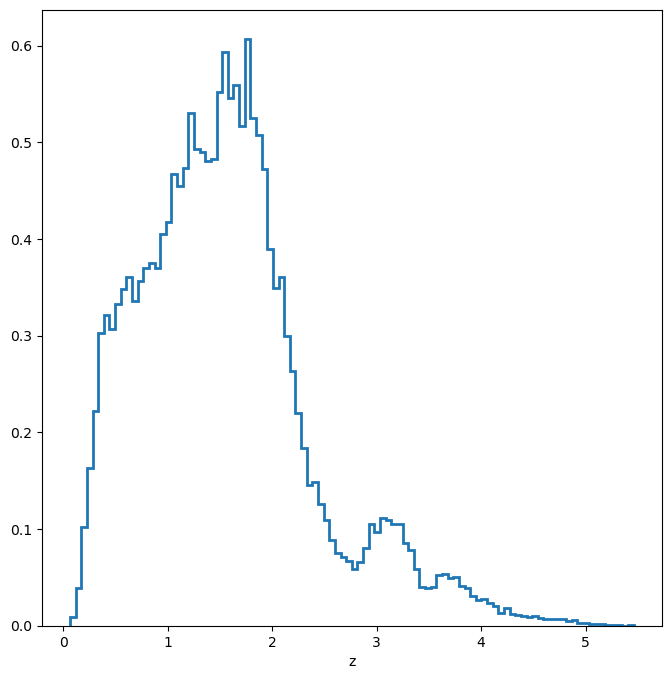

In [4]:
plt.hist(z,bins=100,density=True,histtype='step',lw=2);
plt.xlabel('z')

In [9]:
hist, bin_edges = np.histogram(z, bins=100)

# bin centers
x = (bin_edges[:-1] + bin_edges[1:]) /2
pdf = hist #pdf discreta

### Inverse Transform Sampling

In [10]:
cdf = np.cumsum(pdf)
cdf = cdf / cdf[-1] #normalization

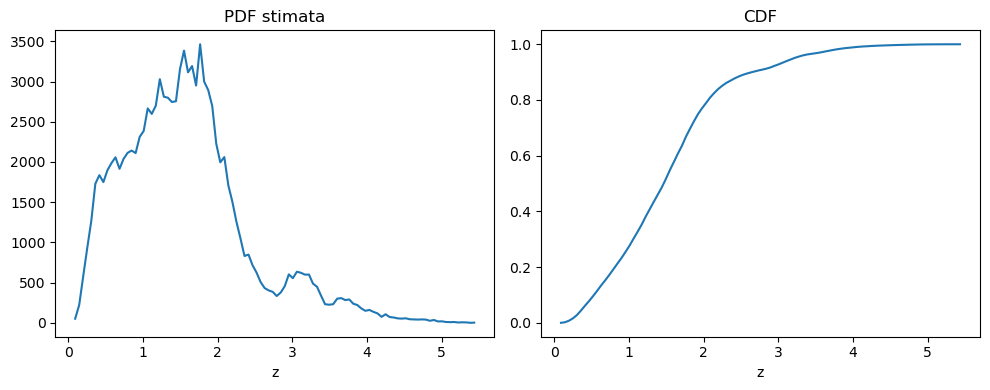

In [12]:
plt.figure(figsize=(10,4))

#pdf
plt.subplot(1,2,1)
plt.plot(x, pdf)
plt.title("PDF stimata")
plt.xlabel("z")

# CDF
plt.subplot(1,2,2)
plt.plot(x, cdf)
plt.title("CDF")
plt.xlabel("z")

plt.tight_layout()
plt.show()

In [11]:
from scipy.interpolate import interp1d

inv_cdf = interp1d(cdf, x, bounds_error=False, fill_value=(x[0], x[-1]))

u = np.random.rand(10000)
samples_inv = inv_cdf(u)

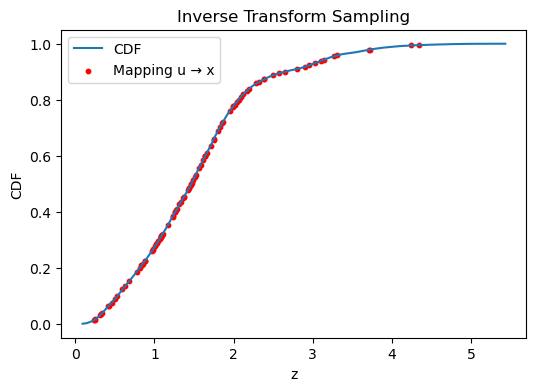

In [13]:
plt.figure(figsize=(6,4))

plt.plot(x, cdf, label="CDF")

# punti uniformi mappati
u_sample = np.random.rand(100)
z_sample = inv_cdf(u_sample)

plt.scatter(z_sample, u_sample, color='red', s=10, label="Mapping u → x")

plt.xlabel("z")
plt.ylabel("CDF")
plt.title("Inverse Transform Sampling")
plt.legend()
plt.show()

### Rejection Sampling